In [1]:
import os
import cv2
import math
from glob import glob
from pathlib import Path

# Parameters
base_magnification = 36000
patch_size = 128
input_root = 'MultiMag'      # e.g. './raw_images'
output_root = 'MultiMag_Patches'   # e.g. './patches'

# Make output root
os.makedirs(output_root, exist_ok=True)

# Process each magnification
for mag_folder in os.listdir(input_root):
    mag_path = os.path.join(input_root, mag_folder)
    if not os.path.isdir(mag_path): continue

    mag = int(mag_folder)
    scale = base_magnification / mag

    for img_path in glob(f"{mag_path}/*"):
        img_name = Path(img_path).stem
        img = cv2.imread(img_path)
        if img is None:
            print(f"Warning: couldn't read {img_path}")
            continue

        # Rescale if needed
        if scale != 1.0:
            new_size = (int(img.shape[1] * scale), int(img.shape[0] * scale))
            img = cv2.resize(img, new_size, interpolation=cv2.INTER_LINEAR)

        h, w = img.shape[:2]
        patch_id = 0
        for y in range(0, h - patch_size + 1, patch_size):
            for x in range(0, w - patch_size + 1, patch_size):
                patch = img[y:y+patch_size, x:x+patch_size]
                patch_name = f"{mag}_{img_name}_patch{patch_id}.png"
                patch_path = os.path.join(output_root, patch_name)
                cv2.imwrite(patch_path, patch)
                patch_id += 1


In [7]:
import os
import json
import random

DATASET_DIR = "MultiMag_Labelled"
OUTPUT_JSON = "dataset_split.json"
# Define your six classes
classes = ["background", "lowfill", "multilayer", "single-hexagonal", "single-square"]

# Use an 80/10/10 split for train/val/test
split_ratio = {"train": 0.8, "val": 0.1, "test": 0.1}
data_split = {"train": {}, "val": {}, "test": {}}

for cls in classes:
    class_dir = os.path.join(DATASET_DIR, cls)
    if not os.path.exists(class_dir):
        print(f"Class folder {cls} not found. Skipping.")
        continue
    images = os.listdir(class_dir)
    random.shuffle(images)
    n = len(images)
    n_train = int(n * split_ratio["train"])
    n_val = int(n * split_ratio["val"])
    train_files = images[:n_train]
    val_files = images[n_train:n_train+n_val]
    test_files = images[n_train+n_val:]
    data_split["train"][cls] = [os.path.join(class_dir, f) for f in train_files]
    data_split["val"][cls] = [os.path.join(class_dir, f) for f in val_files]
    data_split["test"][cls] = [os.path.join(class_dir, f) for f in test_files]

with open(OUTPUT_JSON, "w") as f:
    json.dump(data_split, f, indent=4)
print("JSON split saved.")


JSON split saved.


In [7]:
import os
import json
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
from torchvision import transforms, models
from torchvision.datasets import ImageFolder

# Define a wrapper dataset to apply transforms
class TransformedDataset(Dataset):
    def __init__(self, dataset, transform):
        self.dataset = dataset
        self.transform = transform

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        if self.transform:
            img = self.transform(img)
        return img, label

# Parameters
DATASET_DIR = "MultiMag_Labelled"
OUTPUT_JSON = "dataset_split.json"
batch_size = 32
num_epochs = 50
learning_rate = 0.001

# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Define transforms
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),      # Data augmentation
    transforms.RandomRotation(10),          # Small rotations for robustness
    transforms.ToTensor(),                  # Convert PIL Image to tensor
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])  # ImageNet stats
])

val_test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load the entire dataset without transforms initially
dataset = ImageFolder(root=DATASET_DIR, transform=None)
classes = list(dataset.class_to_idx.keys())
print(f"Classes detected: {classes}")

# Load the JSON split
with open(OUTPUT_JSON, 'r') as f:
    data_split = json.load(f)

# Flatten paths for each split
train_paths = [path for cls in classes for path in data_split['train'][cls]]
val_paths = [path for cls in classes for path in data_split['val'][cls]]
test_paths = [path for cls in classes for path in data_split['test'][cls]]

# Create sets for efficient lookup
train_set = set(train_paths)
val_set = set(val_paths)
test_set = set(test_paths)

# Get indices for each split
train_indices = [i for i, (path, _) in enumerate(dataset.samples) if path in train_set]
val_indices = [i for i, (path, _) in enumerate(dataset.samples) if path in val_set]
test_indices = [i for i, (path, _) in enumerate(dataset.samples) if path in test_set]
print(f"Dataset sizes - Train: {len(train_indices)}, Val: {len(val_indices)}, Test: {len(test_indices)}")

# Create subsets
train_subset = Subset(dataset, train_indices)
val_subset = Subset(dataset, val_indices)
test_subset = Subset(dataset, test_indices)

# Apply transforms to subsets
train_dataset = TransformedDataset(train_subset, train_transform)
val_dataset = TransformedDataset(val_subset, val_test_transform)
test_dataset = TransformedDataset(test_subset, val_test_transform)

# Create data loaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Define the model (ResNet18)
model = models.resnet18(pretrained=False)  # Train from scratch
model.fc = nn.Linear(model.fc.in_features, len(classes))  # Adjust for 6 classes
model.to(device)

# Loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, verbose=True)

# Training loop
best_val_acc = 0.0
for epoch in range(num_epochs):
    # Training phase
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)
    print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {avg_train_loss:.4f}")

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_val_loss = val_loss / len(val_loader)
    val_acc = correct / total
    print(f"Validation Loss: {avg_val_loss:.4f}, Accuracy: {val_acc:.4f}")
    
    # Adjust learning rate based on validation loss
    scheduler.step(avg_val_loss)
    
    # Save the best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), 'best_model.pth')
        print(f"Saved best model with Validation Accuracy: {best_val_acc:.4f}")

# Load best model and evaluate on test set
model.load_state_dict(torch.load('best_model.pth'))
model.eval()
test_correct = 0
test_total = 0
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = torch.max(outputs, 1)
        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()
test_acc = test_correct / test_total
print(f"Test Accuracy: {test_acc:.4f}")

Using device: cuda
Classes detected: ['background', 'lowfill', 'multilayer', 'single-hexagonal', 'single-square']
Dataset sizes - Train: 3067, Val: 380, Test: 389


c:\Users\alexg\anaconda3\lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
c:\Users\alexg\anaconda3\lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
c:\Users\alexg\anaconda3\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Epoch 1/50, Train Loss: 0.3672
Validation Loss: 1.2586, Accuracy: 0.6158
Saved best model with Validation Accuracy: 0.6158
Epoch 2/50, Train Loss: 0.2085
Validation Loss: 0.2536, Accuracy: 0.8974
Saved best model with Validation Accuracy: 0.8974
Epoch 3/50, Train Loss: 0.1664
Validation Loss: 0.2563, Accuracy: 0.9158
Saved best model with Validation Accuracy: 0.9158
Epoch 4/50, Train Loss: 0.1213
Validation Loss: 0.3112, Accuracy: 0.9053
Epoch 5/50, Train Loss: 0.1145
Validation Loss: 0.6256, Accuracy: 0.8553
Epoch 6/50, Train Loss: 0.1100
Validation Loss: 0.1365, Accuracy: 0.9447
Saved best model with Validation Accuracy: 0.9447
Epoch 7/50, Train Loss: 0.0899
Validation Loss: 0.2338, Accuracy: 0.9316
Epoch 8/50, Train Loss: 0.0943
Validation Loss: 0.1394, Accuracy: 0.9500
Saved best model with Validation Accuracy: 0.9500
Epoch 9/50, Train Loss: 0.0922
Validation Loss: 0.1087, Accuracy: 0.9658
Saved best model with Validation Accuracy: 0.9658
Epoch 10/50, Train Loss: 0.0779
Validation 

KeyboardInterrupt: 

C:\Users\alexg\AppData\Local\Temp\ipykernel_90604\688101114.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=de


Found 7 TIFF files.

Processing: 36000 x 1410 Ceta.tif
Background: 68.42%
Low Fill: 0.00%
Multilayer: 0.67%
Single Hexagonal: 29.80%
Single Square: 1.12%


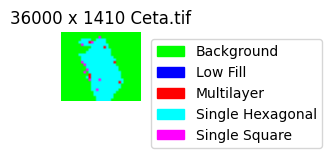


Processing: 36000 x 1646 Ceta.tif
Background: 29.80%
Low Fill: 0.00%
Multilayer: 42.97%
Single Hexagonal: 19.53%
Single Square: 7.70%


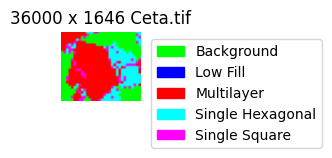


Processing: 36000 x 1648 Ceta.tif
Background: 39.29%
Low Fill: 0.00%
Multilayer: 32.03%
Single Hexagonal: 15.07%
Single Square: 13.62%


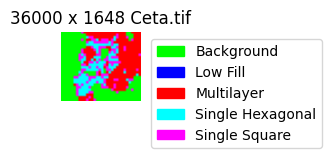


Processing: 36000 x 1713 Ceta.tif
Background: 54.13%
Low Fill: 0.00%
Multilayer: 0.00%
Single Hexagonal: 41.74%
Single Square: 4.13%


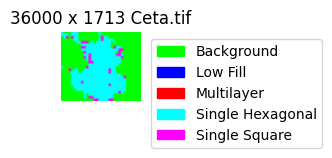


Processing: 36000 x 1749 Ceta.tif
Background: 54.35%
Low Fill: 0.00%
Multilayer: 10.83%
Single Hexagonal: 0.78%
Single Square: 34.04%


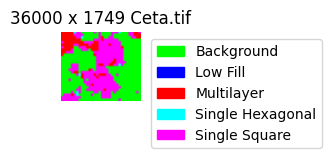


Processing: 36000 x 17492 Ceta.tif
Background: 29.24%
Low Fill: 0.00%
Multilayer: 41.18%
Single Hexagonal: 0.67%
Single Square: 28.91%


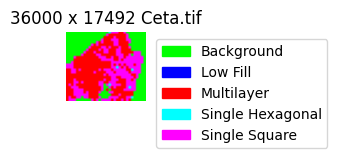


Processing: 36000 x 1822 Ceta.tif
Background: 47.66%
Low Fill: 0.11%
Multilayer: 7.37%
Single Hexagonal: 33.26%
Single Square: 11.61%


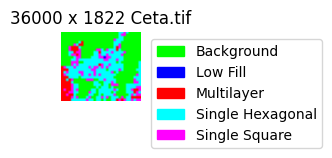

In [11]:
import os
import torch
import torch.nn as nn
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, models
import matplotlib.patches as mpatches

# Parameters
directory = "36kImages"
model_path = 'best_model.pth'
patch_size = 128
batch_size = 32
class_names = ["Background", "Low Fill", "Multilayer", "Single Hexagonal", "Single Square"]
class_colors = {
    0: (0, 255, 0),   # Background
    1: (0, 0, 255),   # Low Fill
    2: (255, 0, 0),   # Multilayer
    3: (0, 255, 255), # Single Hexagonal
    4: (255, 0, 255), # Single Square
}
class_colors_normalized = {k: tuple(c / 255 for c in v) for k, v in class_colors.items()}

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model setup
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 5)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Get TIFF files
if os.path.exists(directory) and os.path.isdir(directory):
    image_files = [f for f in os.listdir(directory) if f.lower().endswith('.tif')]
    print("\nFound", len(image_files), "TIFF files.")

    for file in image_files:
        print(f"\nProcessing: {file}")
        image_path = os.path.join(directory, file)
        image = Image.open(image_path).convert("RGB")
        width, height = image.size
        cropped_image = image.crop((0, 0, width, height - 500))
        image_np = np.array(cropped_image)
        cropped_height, cropped_width, _ = image_np.shape

        # Patch coordinates
        patch_coords = [(x, y) for y in range(0, cropped_height - patch_size + 1, patch_size)
                               for x in range(0, cropped_width - patch_size + 1, patch_size)]
        num_patches = len(patch_coords)

        # Classify patches
        predicted_classes = []
        with torch.no_grad():
            for i in range(0, num_patches, batch_size):
                batch_patches = []
                for j in range(i, min(i + batch_size, num_patches)):
                    x, y = patch_coords[j]
                    patch = image_np[y:y+patch_size, x:x+patch_size, :]
                    patch_tensor = transform(patch)
                    batch_patches.append(patch_tensor)
                batch_tensor = torch.stack(batch_patches).to(device)
                outputs = model(batch_tensor)
                _, preds = torch.max(outputs, 1)
                predicted_classes.extend(preds.cpu().numpy())

        # Reshape prediction map
        num_patches_y = (cropped_height - patch_size) // patch_size + 1
        num_patches_x = (cropped_width - patch_size) // patch_size + 1
        predicted_classes = np.array(predicted_classes).reshape(num_patches_y, num_patches_x)

        # Percentages
        total_patches = num_patches_y * num_patches_x
        class_counts = [np.sum(predicted_classes == label) for label in range(5)]
        percentages = [(count / total_patches) * 100 for count in class_counts]

        for i, percentage in enumerate(percentages):
            print(f"{class_names[i]}: {percentage:.2f}%")

        # Visualization
        small_colormap = np.zeros((num_patches_y, num_patches_x, 3), dtype=np.uint8)
        for i in range(num_patches_y):
            for j in range(num_patches_x):
                class_label = predicted_classes[i, j]
                small_colormap[i, j] = class_colors[class_label]

        plt.figure(figsize=(28.1, 0.9))
        plt.imshow(small_colormap)
        plt.axis('off')
        patches = [mpatches.Patch(color=class_colors_normalized[i], label=class_names[i]) for i in range(5)]
        plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.title(file)
        plt.show()


C:\Users\alexg\AppData\Local\Temp\ipykernel_90604\660473525.py:31: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=de


Found 25 TIFF files.

Processing: 120 kx 1321 Ceta.tif
Background: 11.50%
Low Fill: 0.00%
Multilayer: 0.22%
Single Hexagonal: 80.25%
Single Square: 8.04%


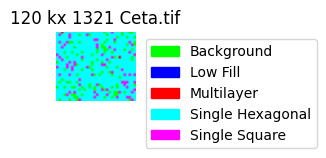


Processing: 120 kx 1649 Ceta.tif
Background: 0.00%
Low Fill: 0.00%
Multilayer: 99.22%
Single Hexagonal: 0.00%
Single Square: 0.78%


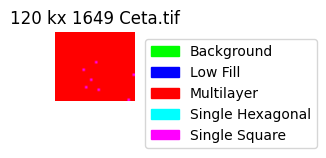


Processing: 120 kx 1651 Ceta.tif
Background: 0.00%
Low Fill: 0.00%
Multilayer: 100.00%
Single Hexagonal: 0.00%
Single Square: 0.00%


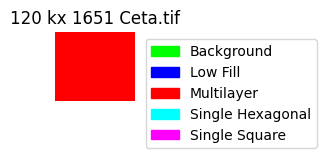


Processing: 120 kx 1659 Ceta.tif
Background: 0.00%
Low Fill: 0.00%
Multilayer: 99.89%
Single Hexagonal: 0.00%
Single Square: 0.11%


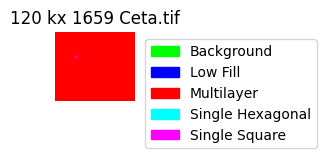


Processing: 120 kx 1710 0001 Ceta.tif
Background: 0.00%
Low Fill: 0.00%
Multilayer: 99.78%
Single Hexagonal: 0.00%
Single Square: 0.22%


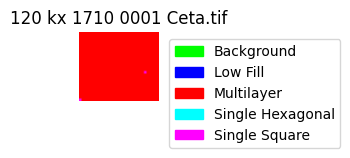


Processing: 120 kx 1710 0002 Ceta.tif
Background: 0.00%
Low Fill: 0.00%
Multilayer: 99.78%
Single Hexagonal: 0.00%
Single Square: 0.22%


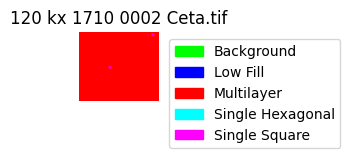


Processing: 120 kx 1714 Ceta.tif
Background: 0.00%
Low Fill: 0.00%
Multilayer: 100.00%
Single Hexagonal: 0.00%
Single Square: 0.00%


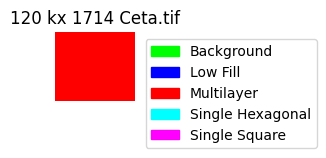


Processing: 120 kx 20220218 Ceta Camera Ceta.tif
Background: 58.59%
Low Fill: 0.33%
Multilayer: 0.45%
Single Hexagonal: 23.33%
Single Square: 17.30%


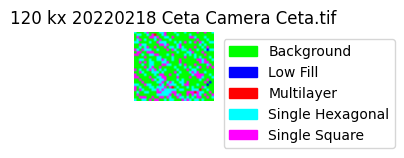


Processing: 120 kx 20221111 Ceta.tif
Background: 16.63%
Low Fill: 0.00%
Multilayer: 6.92%
Single Hexagonal: 61.94%
Single Square: 14.51%


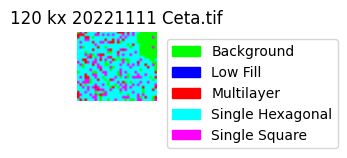


Processing: 150 kx 1812 Ceta.tif
Background: 0.00%
Low Fill: 0.00%
Multilayer: 100.00%
Single Hexagonal: 0.00%
Single Square: 0.00%


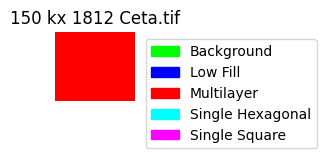


Processing: 20221125 120 kx 0001 Ceta.tif
Background: 9.38%
Low Fill: 0.00%
Multilayer: 7.92%
Single Hexagonal: 45.76%
Single Square: 36.94%


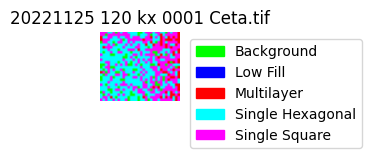


Processing: 20221125 120 kx 0002 Ceta.tif
Background: 24.33%
Low Fill: 0.00%
Multilayer: 0.00%
Single Hexagonal: 69.20%
Single Square: 6.47%


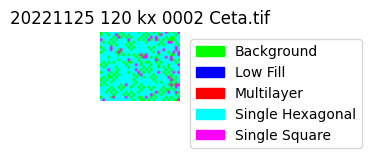


Processing: 20221125 120 kx Ceta.tif
Background: 24.44%
Low Fill: 0.00%
Multilayer: 0.22%
Single Hexagonal: 70.76%
Single Square: 4.58%


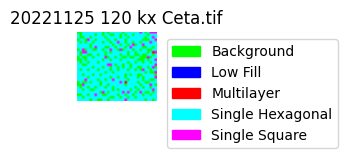


Processing: 20221125 190 kx Ceta.tif
Background: 0.00%
Low Fill: 0.00%
Multilayer: 100.00%
Single Hexagonal: 0.00%
Single Square: 0.00%


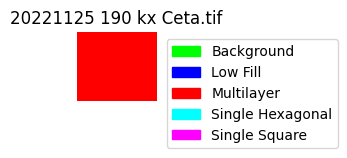


Processing: 36000 x 1410 Ceta.tif
Background: 68.42%
Low Fill: 0.00%
Multilayer: 0.67%
Single Hexagonal: 29.80%
Single Square: 1.12%


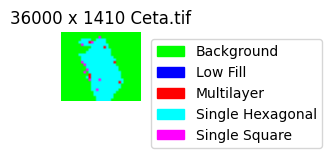


Processing: 36000 x 1646 Ceta.tif
Background: 29.80%
Low Fill: 0.00%
Multilayer: 42.97%
Single Hexagonal: 19.53%
Single Square: 7.70%


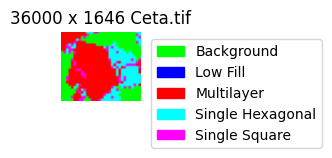


Processing: 36000 x 1648 Ceta.tif
Background: 39.29%
Low Fill: 0.00%
Multilayer: 32.03%
Single Hexagonal: 15.07%
Single Square: 13.62%


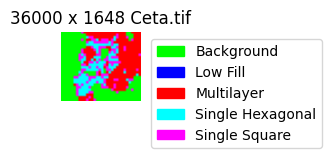


Processing: 36000 x 1652 Ceta.tif
Background: 19.42%
Low Fill: 0.00%
Multilayer: 38.62%
Single Hexagonal: 25.78%
Single Square: 16.18%


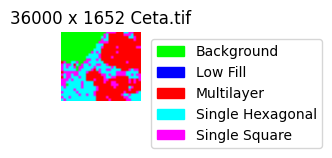


Processing: 36000 x 1713 Ceta.tif
Background: 54.13%
Low Fill: 0.00%
Multilayer: 0.00%
Single Hexagonal: 41.74%
Single Square: 4.13%


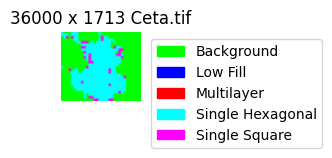


Processing: 36000 x 1749 0002 Ceta.tif
Background: 29.24%
Low Fill: 0.00%
Multilayer: 41.18%
Single Hexagonal: 0.67%
Single Square: 28.91%


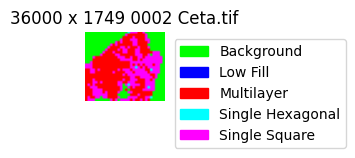


Processing: 36000 x 1749 Ceta.tif
Background: 54.35%
Low Fill: 0.00%
Multilayer: 10.83%
Single Hexagonal: 0.78%
Single Square: 34.04%


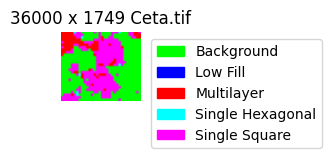


Processing: 36000 x 1822 0001 Ceta.tif
Background: 47.66%
Low Fill: 0.11%
Multilayer: 7.37%
Single Hexagonal: 33.26%
Single Square: 11.61%


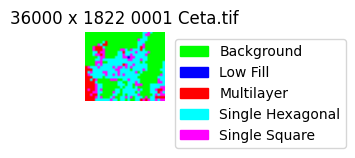


Processing: 3_10.tif
Background: 69.53%
Low Fill: 0.00%
Multilayer: 4.46%
Single Hexagonal: 0.00%
Single Square: 26.00%


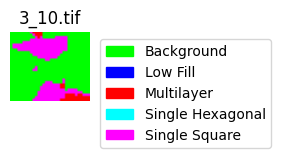


Processing: 46000 x 1625 Ceta.tif
Background: 17.10%
Low Fill: 12.41%
Multilayer: 12.83%
Single Hexagonal: 25.24%
Single Square: 32.41%


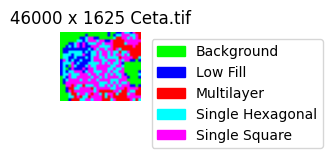


Processing: 46000 x 1811 Ceta.tif
Background: 41.29%
Low Fill: 0.00%
Multilayer: 50.67%
Single Hexagonal: 7.37%
Single Square: 0.67%


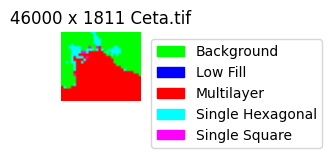

In [12]:
import os
import torch
import torch.nn as nn
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, models
import matplotlib.patches as mpatches

# Parameters
directory = "6H_All_Pics"
model_path = 'best_model.pth'
patch_size = 128
batch_size = 32
class_names = ["Background", "Low Fill", "Multilayer", "Single Hexagonal", "Single Square"]
class_colors = {
    0: (0, 255, 0),   # Background
    1: (0, 0, 255),   # Low Fill
    2: (255, 0, 0),   # Multilayer
    3: (0, 255, 255), # Single Hexagonal
    4: (255, 0, 255), # Single Square
}
class_colors_normalized = {k: tuple(c / 255 for c in v) for k, v in class_colors.items()}

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Model setup
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 5)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Get TIFF files
if os.path.exists(directory) and os.path.isdir(directory):
    image_files = [f for f in os.listdir(directory) if f.lower().endswith('.tif')]
    print("\nFound", len(image_files), "TIFF files.")

    for file in image_files:
        print(f"\nProcessing: {file}")
        image_path = os.path.join(directory, file)
        image = Image.open(image_path).convert("RGB")
        width, height = image.size
        cropped_image = image.crop((0, 0, width, height - 500))
        image_np = np.array(cropped_image)
        cropped_height, cropped_width, _ = image_np.shape

        # Patch coordinates
        patch_coords = [(x, y) for y in range(0, cropped_height - patch_size + 1, patch_size)
                               for x in range(0, cropped_width - patch_size + 1, patch_size)]
        num_patches = len(patch_coords)

        # Classify patches
        predicted_classes = []
        with torch.no_grad():
            for i in range(0, num_patches, batch_size):
                batch_patches = []
                for j in range(i, min(i + batch_size, num_patches)):
                    x, y = patch_coords[j]
                    patch = image_np[y:y+patch_size, x:x+patch_size, :]
                    patch_tensor = transform(patch)
                    batch_patches.append(patch_tensor)
                batch_tensor = torch.stack(batch_patches).to(device)
                outputs = model(batch_tensor)
                _, preds = torch.max(outputs, 1)
                predicted_classes.extend(preds.cpu().numpy())

        # Reshape prediction map
        num_patches_y = (cropped_height - patch_size) // patch_size + 1
        num_patches_x = (cropped_width - patch_size) // patch_size + 1
        predicted_classes = np.array(predicted_classes).reshape(num_patches_y, num_patches_x)

        # Percentages
        total_patches = num_patches_y * num_patches_x
        class_counts = [np.sum(predicted_classes == label) for label in range(5)]
        percentages = [(count / total_patches) * 100 for count in class_counts]

        for i, percentage in enumerate(percentages):
            print(f"{class_names[i]}: {percentage:.2f}%")

        # Visualization
        small_colormap = np.zeros((num_patches_y, num_patches_x, 3), dtype=np.uint8)
        for i in range(num_patches_y):
            for j in range(num_patches_x):
                class_label = predicted_classes[i, j]
                small_colormap[i, j] = class_colors[class_label]

        plt.figure(figsize=(28.1, 0.9))
        plt.imshow(small_colormap)
        plt.axis('off')
        patches = [mpatches.Patch(color=class_colors_normalized[i], label=class_names[i]) for i in range(5)]
        plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.title(file)
        plt.show()


C:\Users\alexg\AppData\Local\Temp\ipykernel_90604\170223609.py:32: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=de


Found 25 TIFF files.

Processing: 120 kx 1321 Ceta.tif


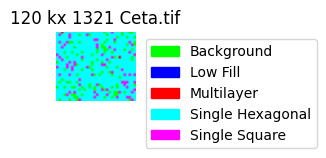


Processing: 120 kx 1649 Ceta.tif


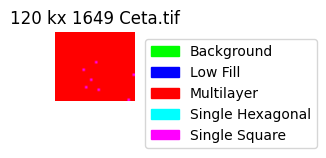


Processing: 120 kx 1651 Ceta.tif


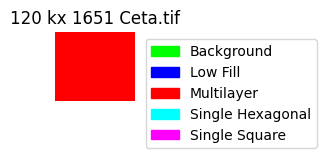


Processing: 120 kx 1659 Ceta.tif


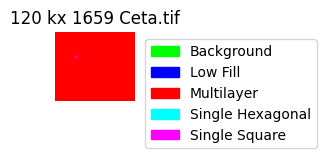


Processing: 120 kx 1710 0001 Ceta.tif


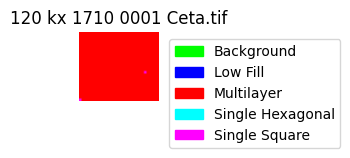


Processing: 120 kx 1710 0002 Ceta.tif


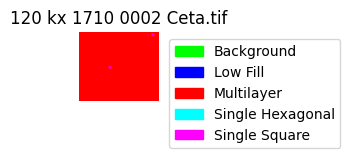


Processing: 120 kx 1714 Ceta.tif


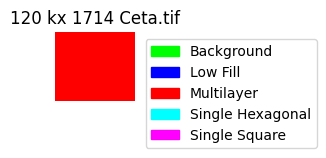


Processing: 120 kx 20220218 Ceta Camera Ceta.tif


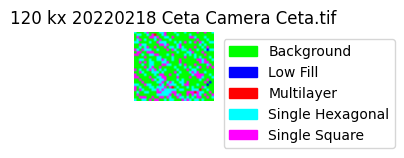


Processing: 120 kx 20221111 Ceta.tif


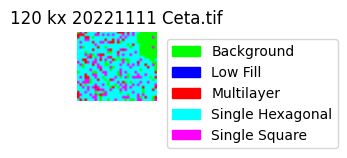


Processing: 150 kx 1812 Ceta.tif


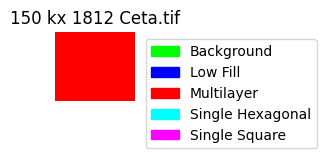


Processing: 20221125 120 kx 0001 Ceta.tif


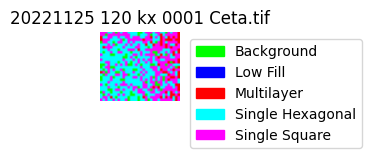


Processing: 20221125 120 kx 0002 Ceta.tif


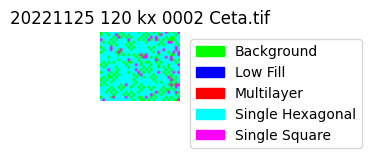


Processing: 20221125 120 kx Ceta.tif


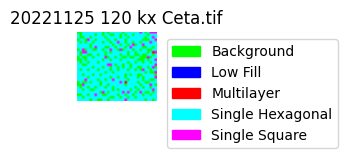


Processing: 20221125 190 kx Ceta.tif


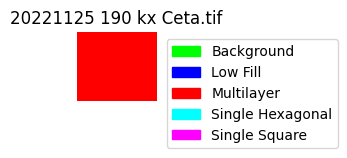


Processing: 36000 x 1410 Ceta.tif


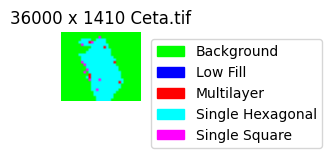


Processing: 36000 x 1646 Ceta.tif


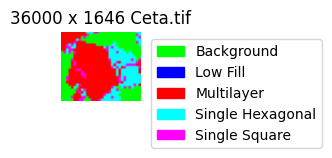


Processing: 36000 x 1648 Ceta.tif


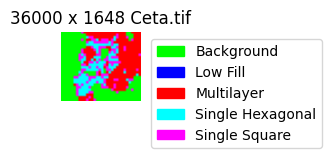


Processing: 36000 x 1652 Ceta.tif


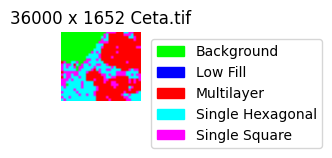


Processing: 36000 x 1713 Ceta.tif


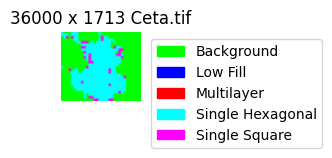


Processing: 36000 x 1749 0002 Ceta.tif


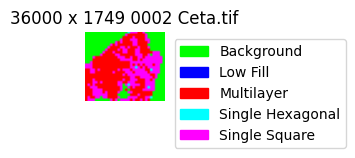


Processing: 36000 x 1749 Ceta.tif


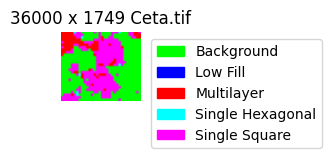


Processing: 36000 x 1822 0001 Ceta.tif


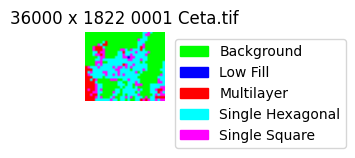


Processing: 3_10.tif


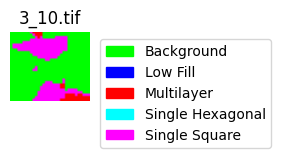


Processing: 46000 x 1625 Ceta.tif


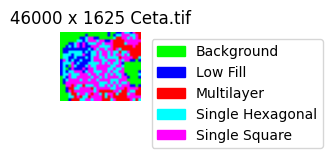


Processing: 46000 x 1811 Ceta.tif


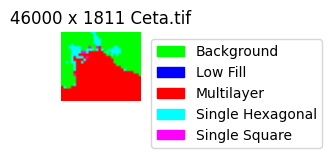

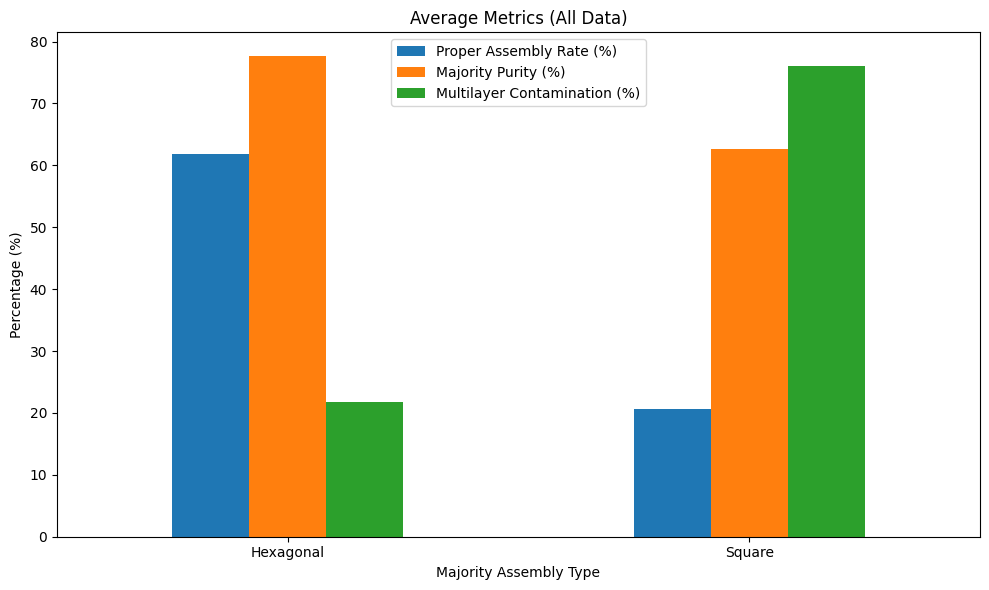

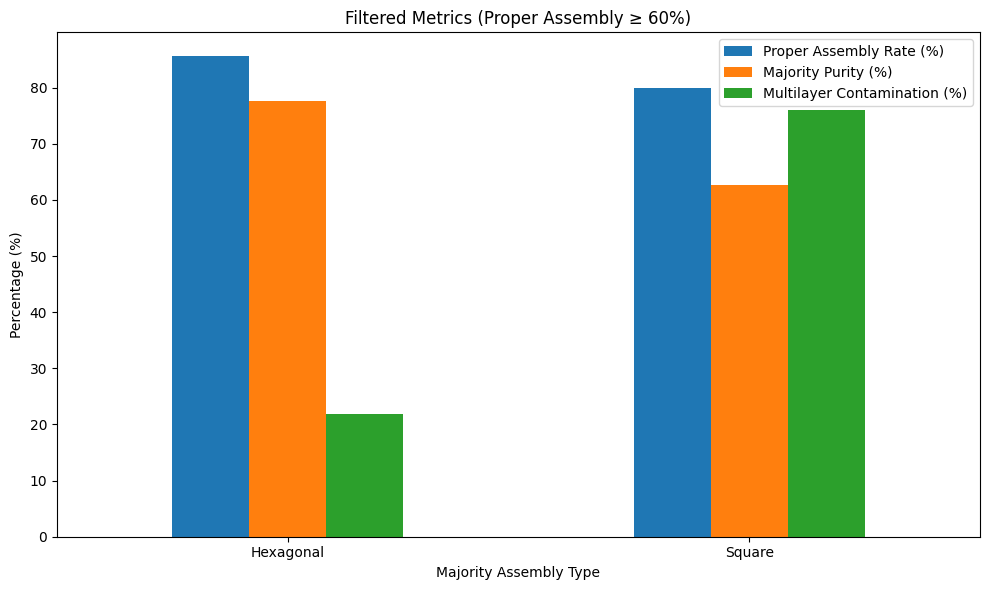

In [13]:
import os
import torch
import torch.nn as nn
from PIL import Image
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from torchvision import transforms, models

# Parameters
directory = "6H_All_Pics"
model_path = 'best_model.pth'
patch_size = 128
batch_size = 32
class_names = ["Background", "Low Fill", "Multilayer", "Single Hexagonal", "Single Square"]
class_colors = {
    0: (0, 255, 0),   # Background
    1: (0, 0, 255),   # Low Fill
    2: (255, 0, 0),   # Multilayer
    3: (0, 255, 255), # Single Hexagonal
    4: (255, 0, 255), # Single Square
}
class_colors_normalized = {k: tuple(c / 255 for c in v) for k, v in class_colors.items()}

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load model
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 5)
model.load_state_dict(torch.load(model_path, map_location=device))
model.to(device)
model.eval()

# Transform
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Storage
new_data = []

# Process images
if os.path.exists(directory) and os.path.isdir(directory):
    image_files = [f for f in os.listdir(directory) if f.lower().endswith('.tif')]
    print("\nFound", len(image_files), "TIFF files.")

    for file in image_files:
        print(f"\nProcessing: {file}")
        image_path = os.path.join(directory, file)
        image = Image.open(image_path).convert("RGB")
        width, height = image.size
        cropped_image = image.crop((0, 0, width, height - 500))
        image_np = np.array(cropped_image)
        cropped_height, cropped_width, _ = image_np.shape

        patch_coords = [(x, y) for y in range(0, cropped_height - patch_size + 1, patch_size)
                               for x in range(0, cropped_width - patch_size + 1, patch_size)]
        num_patches = len(patch_coords)

        predicted_classes = []
        with torch.no_grad():
            for i in range(0, num_patches, batch_size):
                batch_patches = []
                for j in range(i, min(i + batch_size, num_patches)):
                    x, y = patch_coords[j]
                    patch = image_np[y:y+patch_size, x:x+patch_size, :]
                    patch_tensor = transform(patch)
                    batch_patches.append(patch_tensor)
                batch_tensor = torch.stack(batch_patches).to(device)
                outputs = model(batch_tensor)
                _, preds = torch.max(outputs, 1)
                predicted_classes.extend(preds.cpu().numpy())

        num_patches_y = (cropped_height - patch_size) // patch_size + 1
        num_patches_x = (cropped_width - patch_size) // patch_size + 1
        predicted_classes = np.array(predicted_classes).reshape(num_patches_y, num_patches_x)

        # Count and percentages
        total_patches = num_patches_y * num_patches_x
        counts = [np.sum(predicted_classes == label) for label in range(5)]
        percents = [(c / total_patches) * 100 for c in counts]

        d = {
            "file": file,
            "Background": percents[0],
            "Low Fill": percents[1],
            "Multilayer": percents[2],
            "Single Hexagonal": percents[3],
            "Single Square": percents[4]
        }
        new_data.append(d)

        # Visualization (optional)
        small_colormap = np.zeros((num_patches_y, num_patches_x, 3), dtype=np.uint8)
        for i in range(num_patches_y):
            for j in range(num_patches_x):
                class_label = predicted_classes[i, j]
                small_colormap[i, j] = class_colors[class_label]

        plt.figure(figsize=(28.1, 0.9))
        plt.imshow(small_colormap)
        plt.axis('off')
        patches = [mpatches.Patch(color=class_colors_normalized[i], label=class_names[i]) for i in range(5)]
        plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')
        plt.title(file)
        plt.show()

# Augment results
augmented_results = []
for d in new_data:
    hex_pct = d["Single Hexagonal"]
    square_pct = d["Single Square"]
    multi_pct = d["Multilayer"]
    total_structured = hex_pct + square_pct + multi_pct
    total_single = hex_pct + square_pct

    if hex_pct > square_pct:
        majority = "Hexagonal"
        proper = (hex_pct / total_structured) * 100 if total_structured > 0 else 0
        purity = (hex_pct / total_single) * 100 if total_single > 0 else 0
    else:
        majority = "Square"
        proper = (square_pct / total_structured) * 100 if total_structured > 0 else 0
        purity = (square_pct / total_single) * 100 if total_single > 0 else 0

    multilayer_contam = (multi_pct / total_structured) * 100 if total_structured > 0 else 0

    augmented_results.append({
        "Filename": d["file"],
        "Majority Assembly": majority,
        "Proper Assembly Rate (%)": round(proper, 2),
        "Majority Purity (%)": round(purity, 2),
        "Multilayer Contamination (%)": round(multilayer_contam, 2)
    })

augmented_df = pd.DataFrame(augmented_results)
augmented_df.to_csv("assembly_metrics_all.csv", index=False)

# Group averages (all data)
grouped_avg_all = augmented_df.groupby("Majority Assembly")[[
    "Proper Assembly Rate (%)", "Majority Purity (%)", "Multilayer Contamination (%)"
]].mean().round(2)

# Plot all
fig1, ax1 = plt.subplots(figsize=(10, 6))
grouped_avg_all.plot.bar(ax=ax1)
ax1.set_title("Average Metrics (All Data)")
ax1.set_ylabel("Percentage (%)")
ax1.set_xlabel("Majority Assembly Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plot_all_data.png")

# Filtered by Proper Assembly Rate ≥ 60%
filtered_df = augmented_df[augmented_df["Proper Assembly Rate (%)"] >= 60]
filtered_df.to_csv("assembly_metrics_filtered.csv", index=False)

filtered_proper_avg = filtered_df.groupby("Majority Assembly")[[
    "Proper Assembly Rate (%)"
]].mean()
purity_and_contam_avg = augmented_df.groupby("Majority Assembly")[[
    "Majority Purity (%)", "Multilayer Contamination (%)"
]].mean()

final_avg_df = pd.concat([filtered_proper_avg, purity_and_contam_avg], axis=1).round(2)

# Plot filtered
fig2, ax2 = plt.subplots(figsize=(10, 6))
final_avg_df.plot.bar(ax=ax2)
ax2.set_title("Filtered Metrics (Proper Assembly ≥ 60%)")
ax2.set_ylabel("Percentage (%)")
ax2.set_xlabel("Majority Assembly Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plot_filtered_data.png")


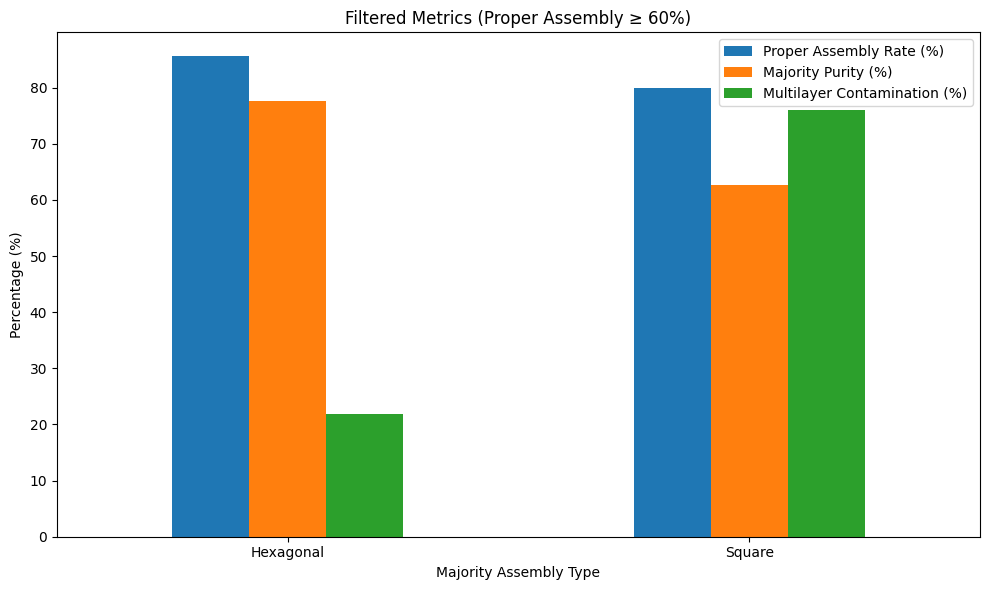

In [14]:
# Plot filtered
fig2, ax2 = plt.subplots(figsize=(10, 6))
final_avg_df.plot.bar(ax=ax2)
ax2.set_title("Filtered Metrics (Proper Assembly ≥ 60%)")
ax2.set_ylabel("Percentage (%)")
ax2.set_xlabel("Majority Assembly Type")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("plot_filtered_data.png")

C:\Users\alexg\AppData\Local\Temp\ipykernel_90604\1010043045.py:20: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path))


Background: 54.35%
Low Fill: 0.00%
Multilayer: 10.83%
Single Hexagonal: 0.78%
Single Square: 34.04%


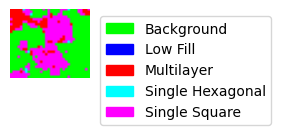

In [10]:
import torch
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms, models
import matplotlib.patches as mpatches

# Parameters
model_path = 'best_model.pth'  # Update this to your model's path
image_path = "36kImages/36000 x 1749 Ceta.tif"
patch_size = 128
batch_size = 32

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load the trained classification model (ResNet18 adjusted for 5 classes)
model = models.resnet18(pretrained=False)
model.fc = nn.Linear(model.fc.in_features, 5)  # 5 classes
model.load_state_dict(torch.load(model_path))
model.to(device)
model.eval()

# Define transformation (same as used during training)
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Load and crop the image (remove bottom 500 pixels)
image = Image.open(image_path).convert("RGB")
width, height = image.size
cropped_image = image.crop((0, 0, width, height - 500))
image_np = np.array(cropped_image)
cropped_height, cropped_width, _ = image_np.shape

# Generate patch coordinates (non-overlapping 128x128 patches)
patch_coords = [(x, y) for y in range(0, cropped_height - patch_size + 1, patch_size)
                       for x in range(0, cropped_width - patch_size + 1, patch_size)]
num_patches = len(patch_coords)

# Classify patches in batches
predicted_classes = []
with torch.no_grad():
    for i in range(0, num_patches, batch_size):
        batch_patches = []
        for j in range(i, min(i + batch_size, num_patches)):
            x, y = patch_coords[j]
            patch = image_np[y:y+patch_size, x:x+patch_size, :]
            patch_tensor = transform(patch)  # Transform accepts numpy array
            batch_patches.append(patch_tensor)
        batch_tensor = torch.stack(batch_patches).to(device)
        outputs = model(batch_tensor)
        _, preds = torch.max(outputs, 1)
        predicted_classes.extend(preds.cpu().numpy())

# Reshape predictions into a 2D grid
num_patches_y = (cropped_height - patch_size) // patch_size + 1
num_patches_x = (cropped_width - patch_size) // patch_size + 1
predicted_classes = np.array(predicted_classes).reshape(num_patches_y, num_patches_x)

# Calculate percentages
total_patches = num_patches_y * num_patches_x
class_counts = [np.sum(predicted_classes == label) for label in range(5)]
percentages = [(count / total_patches) * 100 for count in class_counts]
class_names = ["Background", "Low Fill", "Multilayer", "Single Hexagonal", "Single Square"]

# Print percentages
for i, percentage in enumerate(percentages):
    print(f"{class_names[i]}: {percentage:.2f}%")

# Define class colors (RGB values from 0-255)
class_colors = {
    0: (0, 255, 0),   # Background - Green
    1: (0, 0, 255),   # Low Fill - Blue
    2: (255, 0, 0),   # Multilayer - Red
    3: (0, 255, 255), # Single Hexagonal - Cyan
    4: (255, 0, 255), # Single Square - Magenta
}
class_colors_normalized = {k: tuple(c / 255 for c in v) for k, v in class_colors.items()}

# Create a small colormap (each patch represented by a single pixel)
small_colormap = np.zeros((num_patches_y, num_patches_x, 3), dtype=np.uint8)
for i in range(num_patches_y):
    for j in range(num_patches_x):
        class_label = predicted_classes[i, j]
        small_colormap[i, j] = class_colors[class_label]

# Display the colormap
plt.figure(figsize=(28.1, 0.9))  # Proportional to num_patches_x and num_patches_y
plt.imshow(small_colormap)
plt.axis('off')

# Add legend
patches = [mpatches.Patch(color=class_colors_normalized[i], label=class_names[i]) for i in range(5)]
plt.legend(handles=patches, bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

In [15]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"


In [13]:
import os
import json
import shutil
import numpy as np
from PIL import Image

with open("dataset_split.json", "r") as f:
    data_split = json.load(f)

OUTPUT_DIRS = {
    "train": {"images": "./train_data4/images", "masks": "./train_data4/masks"},
    "val": {"images": "./val_data4/images", "masks": "./val_data4/masks"},
    "test": {"images": "./test_data4/images", "masks": "./test_data4/masks"}
}
for split in OUTPUT_DIRS:
    os.makedirs(OUTPUT_DIRS[split]["images"], exist_ok=True)
    os.makedirs(OUTPUT_DIRS[split]["masks"], exist_ok=True)

# Same class order as before
classes = ["background", "lowfill", "multilayer", "single-hexagonal", "single-square"]

for split, split_data in data_split.items():
    for cls in classes:
        for img_path in split_data.get(cls, []):
            img_name = os.path.basename(img_path)
            dest_img_path = os.path.join(OUTPUT_DIRS[split]["images"], img_name)
            shutil.copy(img_path, dest_img_path)
            # Create a mask of size 128x128 with class index
            mask = np.full((128, 128), classes.index(cls), dtype=np.uint8)
            mask_name = os.path.splitext(img_name)[0] + "_mask.png"
            mask_path = os.path.join(OUTPUT_DIRS[split]["masks"], mask_name)
            Image.fromarray(mask).save(mask_path)

print("Dataset prepared with train/val/test splits and masks.")


Dataset prepared with train/val/test splits and masks.


In [ ]:
import os
import json
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import Sequence
from sklearn.model_selection import train_test_split # Used only for splitting file list if needed
import matplotlib.pyplot as plt
import math

# --- Configuration ---
IMG_HEIGHT = 128
IMG_WIDTH = 128
IMG_CHANNELS = 3 # Assuming RGB images. Change to 1 if grayscale.
NUM_CLASSES = 5
BATCH_SIZE = 16 # Adjust based on your GPU memory
EPOCHS = 50 # Adjust as needed
LEARNING_RATE = 1e-4
MODEL_SAVE_PATH = "unet_pixel_classifier.keras"
DATA_SPLIT_JSON = "dataset_split.json" # Your JSON file

# Directories from your prep script (adjust if different)
TRAIN_IMG_DIR = "./train_data4/images"
TRAIN_MASK_DIR = "./train_data4/masks"
VAL_IMG_DIR = "./val_data4/images"
VAL_MASK_DIR = "./val_data4/masks"
TEST_IMG_DIR = "./test_data4/images" # We'll use this for inference example
TEST_MASK_DIR = "./test_data4/masks" # For potential evaluation later

# Class names (ensure order matches your mask creation)
CLASSES = ["background", "lowfill", "multilayer", "single-hexagonal", "single-square"]

# --- Data Generator ---
class SegmentationDataGenerator(Sequence):
    """Generates data for Keras segmentation models."""
    def __init__(self, image_paths, mask_paths, batch_size, img_size=(IMG_HEIGHT, IMG_WIDTH), n_channels=IMG_CHANNELS, n_classes=NUM_CLASSES, shuffle=True):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.batch_size = batch_size
        self.img_size = img_size
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.shuffle = shuffle
        self.indexes = np.arange(len(self.image_paths))
        self.on_epoch_end()

    def __len__(self):
        """Denotes the number of batches per epoch."""
        return math.ceil(len(self.image_paths) / self.batch_size)

    def __getitem__(self, index):
        """Generate one batch of data."""
        # Generate indexes of the batch
        indexes = self.indexes[index * self.batch_size:(index + 1) * self.batch_size]

        # Find list of IDs
        batch_image_paths = [self.image_paths[k] for k in indexes]
        batch_mask_paths = [self.mask_paths[k] for k in indexes]

        # Generate data
        X, y = self.__data_generation(batch_image_paths, batch_mask_paths)

        return X, y

    def on_epoch_end(self):
        """Updates indexes after each epoch."""
        self.indexes = np.arange(len(self.image_paths))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    def __data_generation(self, batch_image_paths, batch_mask_paths):
        """Generates data containing batch_size samples."""
        # Initialization
        X = np.empty((len(batch_image_paths), *self.img_size, self.n_channels), dtype=np.float32)
        y = np.empty((len(batch_image_paths), *self.img_size, 1), dtype=np.uint8) # Masks are integer class IDs

        # Generate data
        for i, (img_path, mask_path) in enumerate(zip(batch_image_paths, batch_mask_paths)):
            # Load image
            try:
                img = Image.open(img_path).convert('RGB') # Ensure RGB
                if img.size != self.img_size:
                    img = img.resize(self.img_size, Image.Resampling.LANCZOS) # Resize if needed
                img_array = np.array(img) / 255.0 # Normalize to [0, 1]
                X[i,] = img_array

                # Load mask
                mask = Image.open(mask_path)#.convert('L') # Load as grayscale (single channel)
                if mask.size != self.img_size:
                    mask = mask.resize(self.img_size, Image.Resampling.NEAREST) # Use NEAREST for masks!
                mask_array = np.array(mask)
                # Add channel dimension for Keras: (H, W) -> (H, W, 1)
                y[i,] = np.expand_dims(mask_array, axis=-1)

            except FileNotFoundError:
                 print(f"Warning: File not found {img_path} or {mask_path}. Skipping.")
                 # Handle appropriately, maybe skip or fill with zeros
                 # For simplicity here, we might rely on Keras handling potential errors
                 # A more robust solution would check file existence before adding to paths list
                 continue # Skip this item if a file is missing
            except Exception as e:
                 print(f"Warning: Error loading {img_path} or {mask_path}: {e}. Skipping.")
                 continue # Skip this item on other errors


        # Use sparse categorical crossentropy, so masks should be (batch, H, W, 1) with integer labels
        return X, y

# --- Load Data Paths from JSON ---
def get_paths_from_json(data_split_json, split_name, classes):
    with open(data_split_json, "r") as f:
        data_split = json.load(f)

    image_paths = []
    mask_paths = []
    split_data = data_split.get(split_name, {})
    for cls in classes:
        img_files = split_data.get(cls, [])
        for img_path in img_files:
             # Ensure file exists before adding
             if os.path.exists(img_path):
                image_paths.append(img_path)
                img_name = os.path.basename(img_path)
                mask_name = os.path.splitext(img_name)[0] + "_mask.png"
                # Construct expected mask path based on your output structure
                mask_dir = OUTPUT_DIRS[split_name]["masks"] # Use the dict defined in your prep script
                expected_mask_path = os.path.join(mask_dir, mask_name)
                if os.path.exists(expected_mask_path):
                    mask_paths.append(expected_mask_path)
                else:
                     print(f"Warning: Mask file not found for image {img_path} at {expected_mask_path}. Skipping image.")
             else:
                 print(f"Warning: Image file not found: {img_path}. Skipping.")


    # Optional: Zip and shuffle together to maintain correspondence
    if image_paths and mask_paths and len(image_paths) == len(mask_paths): # Ensure we have pairs
        combined = list(zip(image_paths, mask_paths))
        np.random.shuffle(combined)
        image_paths[:], mask_paths[:] = zip(*combined)
    elif len(image_paths) != len(mask_paths):
         print(f"Error: Mismatch between number of images and masks found for split '{split_name}'.")
         # Decide how to handle: raise error, return empty, etc.
         return [], []


    print(f"Found {len(image_paths)} images and {len(mask_paths)} masks for split: {split_name}")
    return image_paths, mask_paths

# Define OUTPUT_DIRS matching your preparation script
OUTPUT_DIRS = {
    "train": {"images": TRAIN_IMG_DIR, "masks": TRAIN_MASK_DIR},
    "val": {"images": VAL_IMG_DIR, "masks": VAL_MASK_DIR},
    "test": {"images": TEST_IMG_DIR, "masks": TEST_MASK_DIR}
}

train_img_paths, train_mask_paths = get_paths_from_json(DATA_SPLIT_JSON, "train", CLASSES)
val_img_paths, val_mask_paths = get_paths_from_json(DATA_SPLIT_JSON, "val", CLASSES)
test_img_paths, test_mask_paths = get_paths_from_json(DATA_SPLIT_JSON, "test", CLASSES) # For later use


# Create Generators if paths were found
if train_img_paths and train_mask_paths:
    train_generator = SegmentationDataGenerator(
        train_img_paths, train_mask_paths, BATCH_SIZE,
        img_size=(IMG_HEIGHT, IMG_WIDTH), n_channels=IMG_CHANNELS, n_classes=NUM_CLASSES
    )
else:
    print("Error: No training data loaded.")
    train_generator = None # Or exit

if val_img_paths and val_mask_paths:
    val_generator = SegmentationDataGenerator(
        val_img_paths, val_mask_paths, BATCH_SIZE,
        img_size=(IMG_HEIGHT, IMG_WIDTH), n_channels=IMG_CHANNELS, n_classes=NUM_CLASSES, shuffle=False # No shuffle for validation
    )
else:
    print("Warning: No validation data loaded.")
    val_generator = None


# --- U-Net Model Definition ---
def unet_model(output_channels: int, input_size=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)):
    """Build a U-Net model."""
    inputs = keras.Input(shape=input_size)

    # Downsampling path (Encoder)
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(inputs)
    conv1 = layers.Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv1)
    pool1 = layers.MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool1)
    conv2 = layers.Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv2)
    pool2 = layers.MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool2)
    conv3 = layers.Conv2D(256, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv3)
    pool3 = layers.MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = layers.Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool3)
    conv4 = layers.Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv4)
    drop4 = layers.Dropout(0.5)(conv4) # Optional dropout
    pool4 = layers.MaxPooling2D(pool_size=(2, 2))(drop4)

    # Bottleneck
    conv5 = layers.Conv2D(1024, 3, activation='relu', padding='same', kernel_initializer='he_normal')(pool4)
    conv5 = layers.Conv2D(1024, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv5)
    drop5 = layers.Dropout(0.5)(conv5) # Optional dropout

    # Upsampling path (Decoder)
    up6 = layers.Conv2DTranspose(512, (2, 2), strides=(2, 2), padding='same')(drop5)
    merge6 = layers.concatenate([drop4, up6], axis=3)
    conv6 = layers.Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge6)
    conv6 = layers.Conv2D(512, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv6)

    up7 = layers.Conv2DTranspose(256, (2, 2), strides=(2, 2), padding='same')(conv6)
    merge7 = layers.concatenate([conv3, up7], axis=3)
    conv7 = layers.Conv2D(256, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge7)
    conv7 = layers.Conv2D(256, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv7)

    up8 = layers.Conv2DTranspose(128, (2, 2), strides=(2, 2), padding='same')(conv7)
    merge8 = layers.concatenate([conv2, up8], axis=3)
    conv8 = layers.Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge8)
    conv8 = layers.Conv2D(128, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv8)

    up9 = layers.Conv2DTranspose(64, (2, 2), strides=(2, 2), padding='same')(conv8)
    merge9 = layers.concatenate([conv1, up9], axis=3)
    conv9 = layers.Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(merge9)
    conv9 = layers.Conv2D(64, 3, activation='relu', padding='same', kernel_initializer='he_normal')(conv9)

    # Output Layer
    # Use softmax for multi-class classification
    outputs = layers.Conv2D(output_channels, (1, 1), activation='softmax')(conv9)

    model = keras.Model(inputs=inputs, outputs=outputs)
    return model

# --- Build and Compile Model ---
model = unet_model(NUM_CLASSES, input_size=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
model.compile(optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
              loss='sparse_categorical_crossentropy', # Use this if masks are integer labels (H, W, 1)
              # loss='categorical_crossentropy', # Use this if masks are one-hot encoded (H, W, C)
              metrics=['accuracy']) # 'accuracy' measures pixel accuracy

model.summary()

# --- Callbacks ---
callbacks = [
    keras.callbacks.ModelCheckpoint(MODEL_SAVE_PATH, save_best_only=True, monitor='val_loss', verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True), # Increase patience if needed
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=1e-6, verbose=1)
]

# --- Training ---
if train_generator and val_generator:
    print("\n--- Starting Training ---")
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=EPOCHS,
        callbacks=callbacks,
        workers=4, # Adjust based on your system
        use_multiprocessing=True
    )
    print("\n--- Training Finished ---")

    # Plot training history (optional)
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Training Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.tight_layout()
    plt.show()

else:
    print("Skipping training due to missing data generators.")


# --- Inference on a Larger Image ---
def predict_large_image(model, large_image_path, patch_size=(IMG_HEIGHT, IMG_WIDTH), stride=None):
    """Predicts segmentation map for a large image using sliding window."""
    if stride is None:
        stride = patch_size[0] // 2 # Default to 50% overlap

    try:
        large_img = Image.open(large_image_path).convert('RGB')
        large_img_np = np.array(large_img) / 255.0
        h, w, c = large_img_np.shape
    except FileNotFoundError:
         print(f"Error: Inference image not found at {large_image_path}")
         return None
    except Exception as e:
        print(f"Error loading inference image {large_image_path}: {e}")
        return None


    ph, pw = patch_size
    sh, sw = stride, stride # Assuming square stride for simplicity

    # Create output arrays to store predictions and counts for averaging
    # Use float32 for summed probabilities, uint8 for final class map
    prediction_sum = np.zeros((h, w, NUM_CLASSES), dtype=np.float32)
    overlap_count = np.zeros((h, w, 1), dtype=np.uint8) # Count how many patches contributed to each pixel

    print(f"Processing large image ({h}x{w}) with patch size {patch_size} and stride {stride}...")

    # Iterate through the large image with the defined stride
    for y in range(0, h - ph + 1, sh):
        for x in range(0, w - pw + 1, sw):
            # Extract patch
            patch = large_img_np[y:y+ph, x:x+pw, :]

            # Model expects batch dimension: (H, W, C) -> (1, H, W, C)
            patch_batch = np.expand_dims(patch, axis=0)

            # Predict probabilities for the patch
            pred_patch_prob = model.predict(patch_batch, verbose=0)[0] # Get prediction for the single patch in the batch

            # Add probabilities to the corresponding region in the large prediction array
            prediction_sum[y:y+ph, x:x+pw, :] += pred_patch_prob
            overlap_count[y:y+ph, x:x+pw, :] += 1

    # Handle edge cases where patches might go out of bounds if h/w not multiple of stride+patch
    # (More complex padding/handling might be needed for full coverage if needed)
    # This simple loop stops when a full patch can't be extracted.

    # Avoid division by zero for pixels never covered (if stride > patch size)
    overlap_count[overlap_count == 0] = 1

    # Average the probabilities where patches overlapped
    final_prediction_prob = prediction_sum / overlap_count

    # Get the class with the highest probability for each pixel
    final_prediction_map = np.argmax(final_prediction_prob, axis=-1).astype(np.uint8)

    print("Inference complete.")
    return final_prediction_map

def visualize_prediction(large_image_path, prediction_map, classes):
    """Displays the original image and the color-coded prediction."""
    try:
        original_img = Image.open(large_image_path).convert('RGB')
    except FileNotFoundError:
        print(f"Cannot visualize: Original image not found at {large_image_path}")
        return
    except Exception as e:
        print(f"Error loading original image for visualization: {e}")
        return


    # Create a color map (customize colors as needed)
    # Ensure this list has at least NUM_CLASSES elements
    colors = np.array([
        [0, 0, 0],       # background (Black)
        [255, 0, 0],     # lowfill (Red)
        [0, 255, 0],     # multilayer (Green)
        [0, 0, 255],     # single-hexagonal (Blue)
        [255, 255, 0],   # single-square (Yellow)
        # Add more colors if you have more classes
    ], dtype=np.uint8)

    # Map class indices to colors
    h, w = prediction_map.shape
    prediction_rgb = np.zeros((h, w, 3), dtype=np.uint8)
    for class_idx in range(len(classes)):
        mask = prediction_map == class_idx
        if class_idx < len(colors):
             prediction_rgb[mask] = colors[class_idx]
        else:
             prediction_rgb[mask] = [128, 128, 128] # Default grey for unexpected classes


    plt.figure(figsize=(15, 7))
    plt.subplot(1, 2, 1)
    plt.imshow(original_img)
    plt.title("Original Large Image")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(prediction_rgb)
    # Create a legend/colorbar (optional, more complex)
    handles = [plt.Rectangle((0,0),1,1, color=tuple(c/255.0 for c in colors[i])) for i in range(len(classes))]
    plt.legend(handles, classes, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.title("Predicted Segmentation Map")
    plt.axis('off')

    plt.tight_layout(rect=[0, 0, 0.85, 1]) # Adjust layout to make space for legend
    plt.show()

# --- Run Inference Example ---
# Load the best saved model
if os.path.exists(MODEL_SAVE_PATH):
    print(f"\n--- Loading trained model from {MODEL_SAVE_PATH} ---")
    inference_model = keras.models.load_model(MODEL_SAVE_PATH)

    # Select an image to test inference on (e.g., one from the test set or any other large image)
    # Make sure this image exists!
    if test_img_paths:
        # Example: use the first image from the test set prepared earlier
        # You would replace this with the path to your actual large image
        large_image_to_predict = test_img_paths[0] # Use a path from your test set for demo
        # OR specify a path directly:
        # large_image_to_predict = "/path/to/your/large_test_image.png"

        print(f"\n--- Running inference on: {large_image_to_predict} ---")

        # Predict using sliding window (adjust stride if desired)
        # Using a stride equal to patch size means non-overlapping patches.
        # Using a smaller stride means overlapping patches, which can give smoother results.
        predicted_map = predict_large_image(inference_model, large_image_to_predict,
                                            patch_size=(IMG_HEIGHT, IMG_WIDTH),
                                            stride=IMG_HEIGHT // 2) # 50% overlap

        if predicted_map is not None:
            # Visualize the result
            visualize_prediction(large_image_to_predict, predicted_map, CLASSES)

            # You can save the predicted map as an image:
            # pred_img = Image.fromarray(predicted_map)
            # pred_img.save("predicted_segmentation.png")
            # Or save the colorized version:
            # (Get prediction_rgb from visualize_prediction or re-generate it)
            # color_pred_img = Image.fromarray(prediction_rgb)
            # color_pred_img.save("predicted_segmentation_color.png")
    else:
        print("No test images found in the JSON split to run inference example.")

else:
    print(f"Trained model not found at {MODEL_SAVE_PATH}. Cannot run inference.")

print("\n--- Script Finished ---")

Found 3067 images and 3067 masks for split: train
Found 380 images and 380 masks for split: val
Found 389 images and 389 masks for split: test
Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 128, 128, 3  0           []                               
                                )]                                                                
                                                                                                  
 conv2d (Conv2D)                (None, 128, 128, 64  1792        ['input_1[0][0]']                
                                )                                                                 
                                                                                                  
 conv2d_1 (Conv2D)              (None, 128, 128, 6

In [ ]:
# Save the model checkpoint
checkpoint_path = "segmentation_model_checkpoint.pth"
torch.save(model.state_dict(), checkpoint_path)
print(f"Model checkpoint saved at {checkpoint_path}")

# Load the model checkpoint
model.load_state_dict(torch.load(checkpoint_path))
print("Model checkpoint loaded successfully") 

Clustering

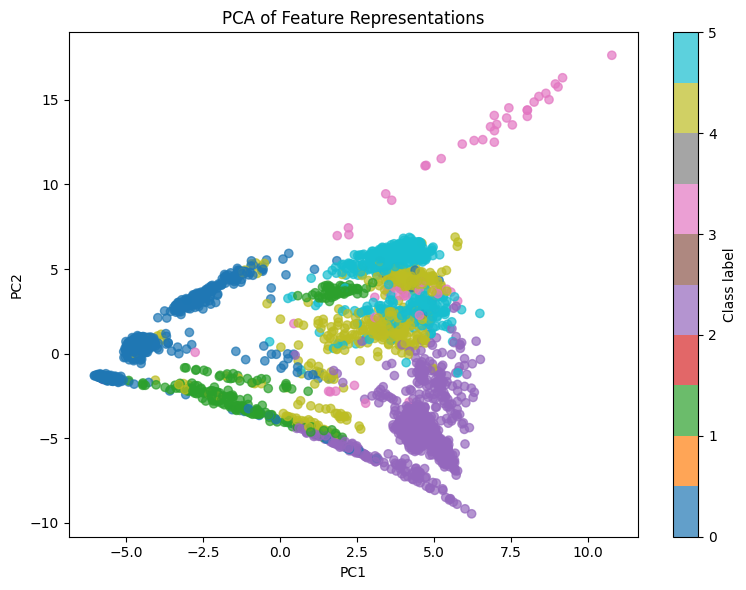

In [15]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Set model to eval
model.eval()
model.cuda()

features = []
labels = []

with torch.no_grad():
    for images, masks in train_loader:
        images = images.cuda()
        masks = masks.cuda()

        # Extract feature maps
        fmap = model.model.extract_features(images)  # Shape: (B, C, H, W)

        # Global average pool to reduce spatial dims
        pooled = torch.mean(fmap, dim=(2, 3))  # Shape: (B, C)

        features.append(pooled.cpu())
        labels.append(masks.view(masks.size(0), -1).mode(1)[0].cpu())  # Majority label per image

features = torch.cat(features).numpy()
labels = torch.cat(labels).numpy()

# PCA
pca = PCA(n_components=2)
proj = pca.fit_transform(features)

# Plot
plt.figure(figsize=(8, 6))
scatter = plt.scatter(proj[:, 0], proj[:, 1], c=labels, cmap='tab10', alpha=0.7)
plt.colorbar(scatter, label="Class label")
plt.title("PCA of Feature Representations")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()


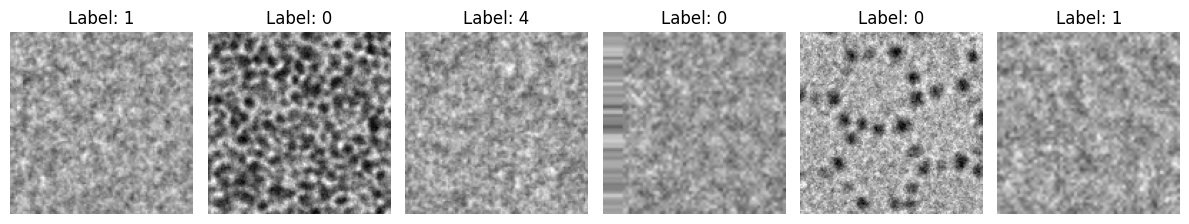

In [16]:
from scipy.spatial.distance import cdist
import numpy as np

# Compute pairwise distances
dists = cdist(proj, proj, metric='euclidean')

# Mask same-label pairs
label_array = labels.reshape(-1, 1)
label_mask = (label_array == label_array.T)

# Set distance to inf if labels match or same index
np.fill_diagonal(dists, np.inf)
dists[label_mask] = np.inf

# Find top-N closest mismatched-label pairs
num_samples = 3
pairs = []
for _ in range(num_samples):
    i, j = np.unravel_index(np.argmin(dists), dists.shape)
    pairs.append((i, j))
    dists[i, j] = np.inf  # prevent reselecting
    dists[j, i] = np.inf

# Unique indices of the mismatched close samples
idxs = list(set([i for i, j in pairs] + [j for i, j in pairs]))
fig, axes = plt.subplots(1, len(idxs), figsize=(12, 4))
for ax, idx in zip(axes, idxs):
    img_path = os.path.join(train_dataset.image_dir, train_dataset.image_paths[idx])
    img = Image.open(img_path).resize((128, 128))
    ax.imshow(img)
    ax.set_title(f"Label: {labels[idx]}")
    ax.axis("off")
plt.tight_layout()
plt.show()
